## Classical Machine Learning — Customer Repurchase Prediction

This section builds a leakage-free machine learning pipeline to predict whether a customer will make another purchase after a defined historical cutoff date.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/clean_transactions.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset shape:", df.shape)
print("\nDate range:")
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

print("\nTransaction types:")
print(df["TransactionType"].value_counts())

Dataset shape: (536642, 18)

Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00

Transaction types:
TransactionType
SALE                              524559
CANCELLATION                        8975
RETURN_OR_NEGATIVE_TRANSACTION      1336
ZERO_PRICE_TRANSACTION              1168
MANUAL_ADJUSTMENT                    567
AMAZON_FEE                            34
BAD_DEBT_ADJUSTMENT                    3
Name: count, dtype: int64


In [2]:
sales_df = df[
    df["TransactionType"] == "SALE"
].copy()

print("Sales dataset shape:", sales_df.shape)

print("\nSales date range:")
print(sales_df["InvoiceDate"].min(), "to", sales_df["InvoiceDate"].max())

print("\nCustomers with Customer ID:",
    sales_df["Customer ID"].notna().sum())

print("Unique identifiable customers:",
    sales_df["Customer ID"].nunique())

Sales dataset shape: (524559, 18)

Sales date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00

Customers with Customer ID: 392414
Unique identifiable customers: 4335


In [4]:
customer_sales = sales_df[
    sales_df["Customer ID"].notna()
].copy()

print("Customer-level sales dataset:", customer_sales.shape)

print("Unique customers:",
    customer_sales["Customer ID"].nunique())

print("Unique orders:",
    customer_sales["Invoice"].nunique())

Customer-level sales dataset: (392414, 18)
Unique customers: 4335
Unique orders: 18468


In [6]:
customer_order_counts = (
    customer_sales
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

print("Customers with 1 order:",
    (customer_order_counts == 1).sum())

print("Customers with 2+ orders:",
    (customer_order_counts >= 2).sum())

print("Customers with 3+ orders:",
    (customer_order_counts >= 3).sum())

print("\nOrder count statistics:")
print(customer_order_counts.describe())

Customers with 1 order: 1496
Customers with 2+ orders: 2839
Customers with 3+ orders: 2003

Order count statistics:
count    4335.000000
mean        4.260208
std         7.659946
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       206.000000
Name: Invoice, dtype: float64


## Temporal Cutoff and Target Creation

This section defines a historical cutoff date and creates a future repurchase target while preventing future information from entering the customer features.

In [7]:
cutoff_date = pd.Timestamp("2011-11-01")

prediction_end = pd.Timestamp("2011-12-01")

print("Feature history ends before:", cutoff_date)
print("Prediction window:", cutoff_date, "to", prediction_end)

Feature history ends before: 2011-11-01 00:00:00
Prediction window: 2011-11-01 00:00:00 to 2011-12-01 00:00:00


In [8]:
historical_sales = customer_sales[
    customer_sales["InvoiceDate"] < cutoff_date
].copy()

future_sales = customer_sales[
    (customer_sales["InvoiceDate"] >= cutoff_date) &
    (customer_sales["InvoiceDate"] < prediction_end)
].copy()

print("Historical sales shape:", historical_sales.shape)
print("Future sales shape:", future_sales.shape)

print("\nHistorical date range:")
print(
    historical_sales["InvoiceDate"].min(),
    "to",
    historical_sales["InvoiceDate"].max()
)

print("\nFuture date range:")
print(
    future_sales["InvoiceDate"].min(),
    "to",
    future_sales["InvoiceDate"].max()
)

Historical sales shape: (312267, 18)
Future sales shape: (63128, 18)

Historical date range:
2010-12-01 08:26:00 to 2011-10-31 17:13:00

Future date range:
2011-11-01 08:16:00 to 2011-11-30 17:37:00


In [9]:
future_customers = set(
    future_sales["Customer ID"].unique()
)

historical_customers = set(
    historical_sales["Customer ID"].unique()
)

print("Historical customers:", len(historical_customers))
print("Future purchasing customers:", len(future_customers))

print(
    "Historical customers who repurchased:",
    len(historical_customers.intersection(future_customers))
)

Historical customers: 3971
Future purchasing customers: 1662
Historical customers who repurchased: 1339


In [10]:
target_df = pd.DataFrame({
    "Customer ID": sorted(historical_customers)
})

target_df["Repurchased"] = (
    target_df["Customer ID"]
    .isin(future_customers)
    .astype(int)
)

print("Target dataset shape:", target_df.shape)

print("\nTarget distribution:")
print(target_df["Repurchased"].value_counts())

print("\nTarget percentage:")
print(
    target_df["Repurchased"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target dataset shape: (3971, 2)

Target distribution:
Repurchased
0    2632
1    1339
Name: count, dtype: int64

Target percentage:
Repurchased
0    66.28
1    33.72
Name: proportion, dtype: float64


In [11]:
target_summary = (
    target_df["Repurchased"]
    .value_counts()
    .rename(index={
        0: "No Repurchase",
        1: "Repurchased"
    })
)

target_summary

Repurchased
No Repurchase    2632
Repurchased      1339
Name: count, dtype: int64

## Leakage-Free Customer Feature Engineering

This section creates customer-level features using only transactions before the prediction cutoff, ensuring that future information does not leak into the machine learning model.

In [12]:
customer_ml_features = (
    historical_sales
    .groupby("Customer ID")
    .agg(
        Total_Orders=("Invoice", "nunique"),
        Total_Revenue=("Revenue", "sum"),
        Total_Units=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_ml_features.head()

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase
0,12346.0,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,6,4085.18,2266,100,2010-12-07 14:57:00,2011-10-31 12:25:00
2,12348.0,4,1797.24,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12350.0,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00
4,12352.0,6,1354.01,406,46,2011-02-16 12:33:00,2011-09-28 14:58:00


In [13]:
analysis_date = cutoff_date

customer_ml_features["Recency_Days"] = (
    analysis_date -
    customer_ml_features["Last_Purchase"]
).dt.days

customer_ml_features["Customer_Lifetime_Days"] = (
    customer_ml_features["Last_Purchase"] -
    customer_ml_features["First_Purchase"]
).dt.days

customer_ml_features["Average_Order_Value"] = (
    customer_ml_features["Total_Revenue"] /
    customer_ml_features["Total_Orders"]
)

customer_ml_features["Average_Units_Per_Order"] = (
    customer_ml_features["Total_Units"] /
    customer_ml_features["Total_Orders"]
)

In [14]:
products_per_order = (
    historical_sales
    .groupby(["Customer ID", "Invoice"])["StockCode"]
    .nunique()
    .groupby("Customer ID")
    .mean()
)

customer_ml_features["Average_Products_Per_Order"] = (
    customer_ml_features["Customer ID"]
    .map(products_per_order)
)

customer_ml_features["Orders_Per_Month"] = (
    customer_ml_features["Total_Orders"] /
    (
        customer_ml_features["Customer_Lifetime_Days"].clip(lower=30)
        / 30
    )
)

customer_ml_features.head()

,Customer ID,Total_Orders,Total_Revenue,Total_Units,Unique_Products,First_Purchase,Last_Purchase,Recency_Days,Customer_Lifetime_Days,Average_Order_Value,Average_Units_Per_Order,Average_Products_Per_Order,Orders_Per_Month
0,12346.0,1,77183.60,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,286,0,77183.600000,74215.000000,1.000000,1.000000
1,12347.0,6,4085.18,2266,100,2010-12-07 14:57:00,2011-10-31 12:25:00,0,327,680.863333,377.666667,28.500000,0.550459
2,12348.0,4,1797.24,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00,36,282,449.310000,585.250000,6.750000,0.425532
3,12350.0,1,334.40,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,271,0,334.400000,197.000000,17.000000,1.000000
4,12352.0,6,1354.01,406,46,2011-02-16 12:33:00,2011-09-28 14:58:00,33,224,225.668333,67.666667,11.166667,0.803571


In [15]:
customer_ml_dataset = customer_ml_features.merge(
    target_df,
    on="Customer ID",
    how="inner"
)

print("ML dataset shape:", customer_ml_dataset.shape)

print("\nTarget distribution:")
print(
    customer_ml_dataset["Repurchased"]
    .value_counts()
)

print("\nMissing values:")
print(
    customer_ml_dataset.isna().sum()
)

ML dataset shape: (3971, 14)

Target distribution:
Repurchased
0    2632
1    1339
Name: count, dtype: int64

Missing values:
Customer ID                   0
Total_Orders                  0
Total_Revenue                 0
Total_Units                   0
Unique_Products               0
First_Purchase                0
Last_Purchase                 0
Recency_Days                  0
Customer_Lifetime_Days        0
Average_Order_Value           0
Average_Units_Per_Order       0
Average_Products_Per_Order    0
Orders_Per_Month              0
Repurchased                   0
dtype: int64


In [16]:
ml_feature_columns = [
    "Total_Orders",
    "Total_Revenue",
    "Total_Units",
    "Unique_Products",
    "Recency_Days",
    "Customer_Lifetime_Days",
    "Average_Order_Value",
    "Average_Units_Per_Order",
    "Average_Products_Per_Order",
    "Orders_Per_Month"
]

customer_ml_dataset[ml_feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Orders,3971.0,3.787459,6.563709,1.000000,1.000000,2.000000,4.000000,156.00
Total_Revenue,3971.0,1804.033577,7800.045162,2.900000,289.780000,622.430000,1509.150000,243102.59
Total_Units,3971.0,1056.932259,4463.997520,1.000000,146.000000,346.000000,871.500000,170637.00
Unique_Products,3971.0,55.707882,76.933818,1.000000,15.000000,33.000000,70.000000,1614.00
Recency_Days,3971.0,93.687232,93.815368,0.000000,20.000000,52.000000,151.500000,334.00
Customer_Lifetime_Days,3971.0,108.277260,115.131126,0.000000,0.000000,70.000000,211.000000,334.00
Average_Order_Value,3971.0,406.559475,1319.544458,2.900000,178.055000,296.401667,433.731000,77183.60
Average_Units_Per_Order,3971.0,249.393973,1215.501284,1.000000,91.000000,160.000000,273.800000,74215.00
Average_Products_Per_Order,3971.0,21.402438,19.012423,1.000000,9.400000,16.666667,27.291667,259.00
Orders_Per_Month,3971.0,1.038998,0.869889,0.184615,0.663717,1.000000,1.000000,34.00


In [17]:
print("Infinite values:")
print(
    np.isinf(
        customer_ml_dataset[ml_feature_columns]
    ).sum().sum()
)

print("\nNegative values:")
print(
    (
        customer_ml_dataset[ml_feature_columns] < 0
    ).sum()
)

Infinite values:
0

Negative values:
Total_Orders                  0
Total_Revenue                 0
Total_Units                   0
Unique_Products               0
Recency_Days                  0
Customer_Lifetime_Days        0
Average_Order_Value           0
Average_Units_Per_Order       0
Average_Products_Per_Order    0
Orders_Per_Month              0
dtype: int64


## Train-Test Split and Preprocessing

This section separates the customer dataset into training and test sets and prepares numerical features for machine learning without using information from the test set during preprocessing.

In [23]:
X = customer_ml_dataset[ml_feature_columns].copy()
y = customer_ml_dataset["Repurchased"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Feature matrix shape: (3971, 10)
Target shape: (3971,)

Target distribution:
Repurchased
0    2632
1    1339
Name: count, dtype: int64

Target distribution (%):
Repurchased
0    66.28
1    33.72
Name: proportion, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

X_train: (3176, 10)
X_test: (795, 10)
y_train: (3176,)
y_test: (795,)

Training target distribution:
Repurchased
0    66.28
1    33.72
Name: proportion, dtype: float64

Test target distribution:
Repurchased
0    66.29
1    33.71
Name: proportion, dtype: float64


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("\nTraining feature means after scaling:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nTraining feature standard deviations after scaling:")
print(np.round(X_train_scaled.std(axis=0), 4))

Scaled training shape: (3176, 10)
Scaled test shape: (795, 10)

Training feature means after scaling:
[ 0.  0. -0. -0. -0.  0.  0. -0. -0. -0.]

Training feature standard deviations after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [26]:
print("Scaler fitted on training data only:", True)

print("\nOriginal training rows:", len(X_train))
print("Original test rows:", len(X_test))

print("\nTotal rows:", len(X_train) + len(X_test))
print("Expected rows:", len(customer_ml_dataset))

Scaler fitted on training data only: True

Original training rows: 3176
Original test rows: 795

Total rows: 3971
Expected rows: 3971


## Logistic Regression Baseline

This section establishes a baseline classification model for customer repurchase prediction using Logistic Regression.

In [27]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [28]:
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated:", len(y_pred_logistic))

print("\nFirst 10 predictions:")
print(y_pred_logistic[:10])

print("\nFirst 10 predicted probabilities:")
print(np.round(y_prob_logistic[:10], 4))

Predictions generated: 795

First 10 predictions:
[1 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.9939 0.3427 0.2047 0.1902 0.1975 0.2347 0.3224 0.3814 0.197  0.1522]


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression Results")
print("----------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")

Logistic Regression Results
----------------------------
Accuracy : 0.7245
Precision: 0.6929
Recall   : 0.3284
F1 Score : 0.4456
ROC-AUC  : 0.7429


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Repurchase", "Repurchased"]
    )
)

Confusion Matrix:
[[488  39]
 [180  88]]

Classification Report:
               precision    recall  f1-score   support

No Repurchase       0.73      0.93      0.82       527
  Repurchased       0.69      0.33      0.45       268

     accuracy                           0.72       795
    macro avg       0.71      0.63      0.63       795
 weighted avg       0.72      0.72      0.69       795



In [31]:
logistic_coefficients = pd.DataFrame({
    "Feature": ml_feature_columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["Absolute_Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients = (
    logistic_coefficients
    .sort_values("Absolute_Coefficient", ascending=False)
)

logistic_coefficients

,Feature,Coefficient,Absolute_Coefficient
0,Total_Orders,1.412615,1.412615
1,Total_Revenue,0.852084,0.852084
6,Average_Order_Value,-0.676086,0.676086
4,Recency_Days,-0.230880,0.230880
8,Average_Products_Per_Order,0.186414,0.186414
9,Orders_Per_Month,-0.150938,0.150938
2,Total_Units,-0.128446,0.128446
3,Unique_Products,0.105851,0.105851
5,Customer_Lifetime_Days,-0.059667,0.059667
7,Average_Units_Per_Order,0.030924,0.030924


## Random Forest

This section trains a Random Forest classifier to capture nonlinear relationships between customer behavior and future repurchase activity.

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [33]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(y_pred_rf))

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 predicted probabilities:")
print(np.round(y_prob_rf[:10], 4))

Predictions generated: 795

First 10 predictions:
[1 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.9567 0.66   0.11   0.1733 0.1867 0.26   0.3233 0.29   0.38   0.14  ]


In [34]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.7157
Precision: 0.5905
Recall   : 0.5112
F1 Score : 0.5480
ROC-AUC  : 0.7129


In [35]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Repurchase", "Repurchased"]
    )
)

Confusion Matrix:
[[432  95]
 [131 137]]

Classification Report:
               precision    recall  f1-score   support

No Repurchase       0.77      0.82      0.79       527
  Repurchased       0.59      0.51      0.55       268

     accuracy                           0.72       795
    macro avg       0.68      0.67      0.67       795
 weighted avg       0.71      0.72      0.71       795



In [36]:
rf_importance = pd.DataFrame({
    "Feature": ml_feature_columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values("Importance", ascending=False)
)

rf_importance

,Feature,Importance
1,Total_Revenue,0.130063
4,Recency_Days,0.123474
2,Total_Units,0.121964
6,Average_Order_Value,0.105096
3,Unique_Products,0.104425
7,Average_Units_Per_Order,0.098522
8,Average_Products_Per_Order,0.088110
5,Customer_Lifetime_Days,0.079378
0,Total_Orders,0.078995
9,Orders_Per_Month,0.069972


## Random Forest Hyperparameter Tuning

This section uses stratified cross-validation and GridSearchCV to identify a stronger Random Forest configuration for customer repurchase prediction.

In [38]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

print("Hyperparameter combinations:", 
    np.prod([len(v) for v in rf_param_grid.values()]))

Hyperparameter combinations: 96


In [39]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Grid search completed.")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Grid search completed.


In [40]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(round(rf_grid.best_score_, 4))

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}

Best Cross-Validation F1:
0.5699


In [41]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned)
rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned)
rf_tuned_roc_auc = roc_auc_score(y_test, y_prob_rf_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"Accuracy : {rf_tuned_accuracy:.4f}")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall   : {rf_tuned_recall:.4f}")
print(f"F1 Score : {rf_tuned_f1:.4f}")
print(f"ROC-AUC  : {rf_tuned_roc_auc:.4f}")

Tuned Random Forest Results
---------------------------
Accuracy : 0.7182
Precision: 0.5840
Recall   : 0.5709
F1 Score : 0.5774
ROC-AUC  : 0.7315


In [42]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        target_names=["No Repurchase", "Repurchased"]
    )
)

Confusion Matrix:
[[418 109]
 [115 153]]

Classification Report:
               precision    recall  f1-score   support

No Repurchase       0.78      0.79      0.79       527
  Repurchased       0.58      0.57      0.58       268

     accuracy                           0.72       795
    macro avg       0.68      0.68      0.68       795
 weighted avg       0.72      0.72      0.72       795



## XGBoost

This section trains an XGBoost classifier to model nonlinear relationships between customer behavior and future repurchase activity.

In [43]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [44]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(y_pred_xgb))

print("\nFirst 10 predictions:")
print(y_pred_xgb[:10])

print("\nFirst 10 predicted probabilities:")
print(np.round(y_prob_xgb[:10], 4))

Predictions generated: 795

First 10 predictions:
[1 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.9857 0.559  0.102  0.175  0.0563 0.1929 0.2681 0.2129 0.2743 0.0595]


In [45]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
----------------
Accuracy : 0.7245
Precision: 0.6485
Recall   : 0.3993
F1 Score : 0.4942
ROC-AUC  : 0.7061


In [46]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Repurchase", "Repurchased"]
    )
)

Confusion Matrix:
[[469  58]
 [161 107]]

Classification Report:
               precision    recall  f1-score   support

No Repurchase       0.74      0.89      0.81       527
  Repurchased       0.65      0.40      0.49       268

     accuracy                           0.72       795
    macro avg       0.70      0.64      0.65       795
 weighted avg       0.71      0.72      0.70       795



In [47]:
xgb_importance = pd.DataFrame({
    "Feature": ml_feature_columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

xgb_importance

,Feature,Importance
0,Total_Orders,0.420732
1,Total_Revenue,0.073060
2,Unique_Products,0.068474
3,Orders_Per_Month,0.066502
4,Customer_Lifetime_Days,0.065753
5,Recency_Days,0.064487
6,Total_Units,0.063582
7,Average_Units_Per_Order,0.060685
8,Average_Products_Per_Order,0.059480
9,Average_Order_Value,0.057244


## XGBoost Hyperparameter Tuning

This section uses stratified cross-validation and GridSearchCV to tune XGBoost for customer repurchase prediction.

In [48]:
xgb_param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

print(
    "Hyperparameter combinations:",
    np.prod([len(v) for v in xgb_param_grid.values()])
)

Hyperparameter combinations: 36


In [49]:
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("XGBoost GridSearchCV completed.")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
XGBoost GridSearchCV completed.


In [50]:
print("Best Parameters:")
print(xgb_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(round(xgb_grid.best_score_, 4))

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'subsample': 0.8}

Best Cross-Validation F1:
0.5164


In [51]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)
xgb_tuned_precision = precision_score(y_test, y_pred_xgb_tuned)
xgb_tuned_recall = recall_score(y_test, y_pred_xgb_tuned)
xgb_tuned_f1 = f1_score(y_test, y_pred_xgb_tuned)
xgb_tuned_roc_auc = roc_auc_score(y_test, y_prob_xgb_tuned)

print("Tuned XGBoost Results")
print("---------------------")
print(f"Accuracy : {xgb_tuned_accuracy:.4f}")
print(f"Precision: {xgb_tuned_precision:.4f}")
print(f"Recall   : {xgb_tuned_recall:.4f}")
print(f"F1 Score : {xgb_tuned_f1:.4f}")
print(f"ROC-AUC  : {xgb_tuned_roc_auc:.4f}")

Tuned XGBoost Results
---------------------
Accuracy : 0.7384
Precision: 0.7055
Recall   : 0.3843
F1 Score : 0.4976
ROC-AUC  : 0.7373


In [52]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb_tuned,
        target_names=["No Repurchase", "Repurchased"]
    )
)

Confusion Matrix:
[[484  43]
 [165 103]]

Classification Report:
               precision    recall  f1-score   support

No Repurchase       0.75      0.92      0.82       527
  Repurchased       0.71      0.38      0.50       268

     accuracy                           0.74       795
    macro avg       0.73      0.65      0.66       795
 weighted avg       0.73      0.74      0.71       795



## Model Comparison

This section compares the trained classification models using accuracy, precision, recall, F1 score, and ROC-AUC to select the most suitable model for customer repurchase prediction.

In [53]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        rf_accuracy,
        rf_tuned_accuracy,
        xgb_accuracy,
        xgb_tuned_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        rf_precision,
        rf_tuned_precision,
        xgb_precision,
        xgb_tuned_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        rf_recall,
        rf_tuned_recall,
        xgb_recall,
        xgb_tuned_recall
    ],
    "F1": [
        f1_score(y_test, y_pred_logistic),
        rf_f1,
        rf_tuned_f1,
        xgb_f1,
        xgb_tuned_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        rf_roc_auc,
        rf_tuned_roc_auc,
        xgb_roc_auc,
        xgb_tuned_roc_auc
    ]
})

model_comparison = model_comparison.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Random Forest,0.7182,0.5840,0.5709,0.5774,0.7315
1,Random Forest,0.7157,0.5905,0.5112,0.5480,0.7129
2,Tuned XGBoost,0.7384,0.7055,0.3843,0.4976,0.7373
3,XGBoost,0.7245,0.6485,0.3993,0.4942,0.7061
4,Logistic Regression,0.7245,0.6929,0.3284,0.4456,0.7429


In [54]:
best_model_row = model_comparison.iloc[0]

print("Best Model:", best_model_row["Model"])
print("Best F1 Score:", round(best_model_row["F1"], 4))
print("Recall:", round(best_model_row["Recall"], 4))
print("ROC-AUC:", round(best_model_row["ROC-AUC"], 4))

Best Model: Tuned Random Forest
Best F1 Score: 0.5774
Recall: 0.5709
ROC-AUC: 0.7315


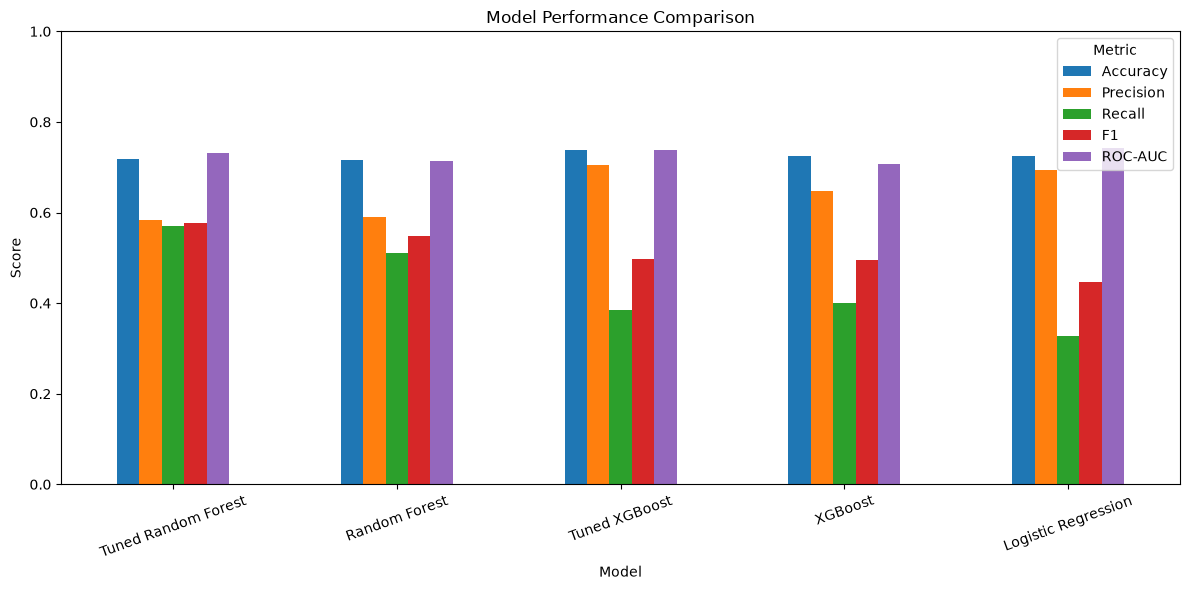

In [55]:
import matplotlib.pyplot as plt

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

ax = model_comparison.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [56]:
final_model = best_rf

print("Final selected model: Tuned Random Forest")
print("\nBest Parameters:")
print(final_model.get_params())

Final selected model: Tuned Random Forest

Best Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 400, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## Feature Importance and Model Interpretation

This section interprets the selected Random Forest model to identify the customer behavior patterns most associated with future repurchase.

In [57]:
final_rf_importance = pd.DataFrame({
    "Feature": ml_feature_columns,
    "Importance": final_model.feature_importances_
})

final_rf_importance = (
    final_rf_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

final_rf_importance

,Feature,Importance
0,Total_Revenue,0.129007
1,Total_Orders,0.123046
2,Total_Units,0.121189
3,Recency_Days,0.112550
4,Unique_Products,0.107532
5,Customer_Lifetime_Days,0.090659
6,Average_Order_Value,0.086001
7,Average_Units_Per_Order,0.080699
8,Average_Products_Per_Order,0.078041
9,Orders_Per_Month,0.071276


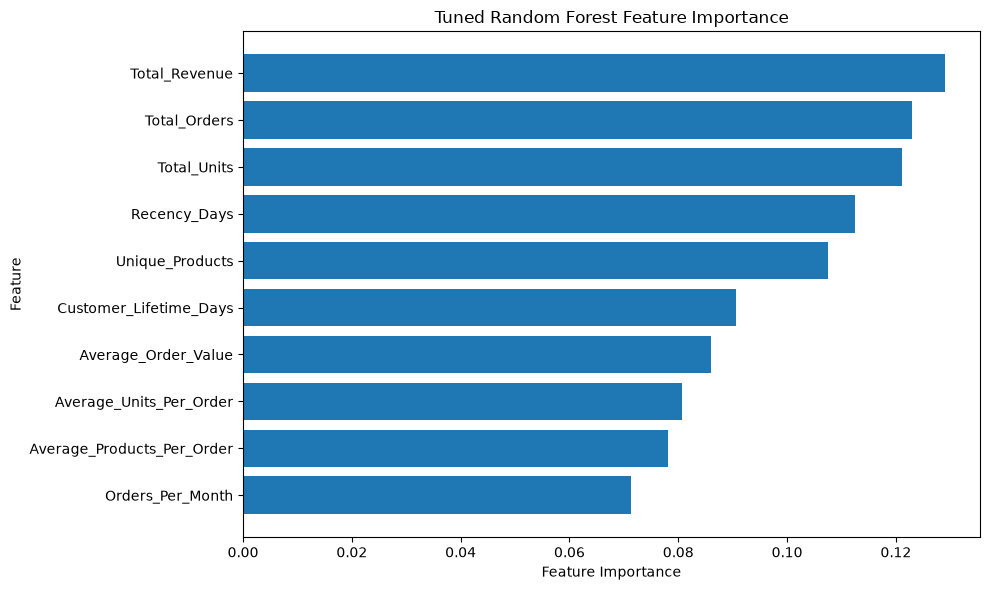

In [58]:
plt.figure(figsize=(10, 6))

plt.barh(
    final_rf_importance["Feature"][::-1],
    final_rf_importance["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Tuned Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [59]:
final_rf_importance["Importance_Pct"] = (
    final_rf_importance["Importance"] * 100
)

final_rf_importance.round(2)

,Feature,Importance,Importance_Pct
0,Total_Revenue,0.13,12.90
1,Total_Orders,0.12,12.30
2,Total_Units,0.12,12.12
3,Recency_Days,0.11,11.26
4,Unique_Products,0.11,10.75
5,Customer_Lifetime_Days,0.09,9.07
6,Average_Order_Value,0.09,8.60
7,Average_Units_Per_Order,0.08,8.07
8,Average_Products_Per_Order,0.08,7.80
9,Orders_Per_Month,0.07,7.13


## Final Machine Learning Conclusions

The customer repurchase prediction task was evaluated using Logistic Regression, Random Forest, and XGBoost models. Random Forest was further optimized using 5-fold cross-validation and GridSearchCV.

The tuned Random Forest achieved the strongest F1 score and recall among the evaluated models, making it the selected model for identifying customers likely to make another purchase.

Historical customer value, order frequency, purchase volume, recency, and product diversity were the most important predictive features.

In [60]:
print("FINAL MODEL")
print("-----------")
print("Model: Tuned Random Forest")
print(f"Accuracy : {rf_tuned_accuracy:.4f}")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall   : {rf_tuned_recall:.4f}")
print(f"F1 Score : {rf_tuned_f1:.4f}")
print(f"ROC-AUC  : {rf_tuned_roc_auc:.4f}")

print("\nBest Hyperparameters:")
print(rf_grid.best_params_)

FINAL MODEL
-----------
Model: Tuned Random Forest
Accuracy : 0.7182
Precision: 0.5840
Recall   : 0.5709
F1 Score : 0.5774
ROC-AUC  : 0.7315

Best Hyperparameters:
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


In [61]:
print("KEY BUSINESS INSIGHTS")
print("---------------------")

print("1. Historical customer revenue was the most important feature.")
print("2. Order frequency and purchase volume were also strong predictors.")
print("3. Recency was among the top predictive features.")
print("4. Product diversity contributed meaningfully to repurchase prediction.")
print("5. The tuned Random Forest achieved the best F1 and recall among tested models.")

KEY BUSINESS INSIGHTS
---------------------
1. Historical customer revenue was the most important feature.
2. Order frequency and purchase volume were also strong predictors.
3. Recency was among the top predictive features.
4. Product diversity contributed meaningfully to repurchase prediction.
5. The tuned Random Forest achieved the best F1 and recall among tested models.


In [62]:
model_comparison.to_csv(
    "../data/model_comparison.csv",
    index=False
)

final_rf_importance.to_csv(
    "../data/final_rf_feature_importance.csv",
    index=False
)

print("Model comparison saved.")
print("Feature importance saved.")

Model comparison saved.
Feature importance saved.


## Advanced Temporal Feature Engineering

This section adds temporal and behavioral customer features using only transactions available before the prediction cutoff. The goal is to capture recent purchasing activity, purchase frequency, spending trends, and changes in customer behavior.

In [63]:
historical = historical_sales.copy()

historical["InvoiceDate"] = pd.to_datetime(historical["InvoiceDate"])

# Order-level information
order_level = (
    historical
    .groupby(["Customer ID", "Invoice"])
    .agg(
        Order_Date=("InvoiceDate", "min"),
        Order_Revenue=("Revenue", "sum"),
        Order_Units=("Quantity", "sum"),
        Order_Products=("StockCode", "nunique")
    )
    .reset_index()
)

# Sort orders chronologically
order_level = order_level.sort_values(
    ["Customer ID", "Order_Date"]
)

# Time since previous order
order_level["Days_Since_Previous_Order"] = (
    order_level
    .groupby("Customer ID")["Order_Date"]
    .diff()
    .dt.total_seconds()
    / 86400
)

# Customer-level temporal features
temporal_features = (
    order_level
    .groupby("Customer ID")
    .agg(
        Avg_Days_Between_Orders=("Days_Since_Previous_Order", "mean"),
        Median_Days_Between_Orders=("Days_Since_Previous_Order", "median"),
        Min_Days_Between_Orders=("Days_Since_Previous_Order", "min"),
        Max_Days_Between_Orders=("Days_Since_Previous_Order", "max")
    )
    .reset_index()
)

# Recent activity windows
recent_30 = historical[
    historical["InvoiceDate"] >= cutoff_date - pd.Timedelta(days=30)
]

recent_60 = historical[
    historical["InvoiceDate"] >= cutoff_date - pd.Timedelta(days=60)
]

recent_90 = historical[
    historical["InvoiceDate"] >= cutoff_date - pd.Timedelta(days=90)
]

recent_30_features = (
    recent_30
    .groupby("Customer ID")
    .agg(
        Orders_Last_30_Days=("Invoice", "nunique"),
        Revenue_Last_30_Days=("Revenue", "sum"),
        Units_Last_30_Days=("Quantity", "sum"),
        Products_Last_30_Days=("StockCode", "nunique")
    )
    .reset_index()
)

recent_60_features = (
    recent_60
    .groupby("Customer ID")
    .agg(
        Orders_Last_60_Days=("Invoice", "nunique"),
        Revenue_Last_60_Days=("Revenue", "sum")
    )
    .reset_index()
)

recent_90_features = (
    recent_90
    .groupby("Customer ID")
    .agg(
        Orders_Last_90_Days=("Invoice", "nunique"),
        Revenue_Last_90_Days=("Revenue", "sum")
    )
    .reset_index()
)

print("Temporal feature tables created.")

Temporal feature tables created.


In [64]:
advanced_features = (
    customer_ml_features[
        ["Customer ID"] + ml_feature_columns
    ]
    .merge(temporal_features, on="Customer ID", how="left")
    .merge(recent_30_features, on="Customer ID", how="left")
    .merge(recent_60_features, on="Customer ID", how="left")
    .merge(recent_90_features, on="Customer ID", how="left")
)

# Fill zero for customers with no activity in a recent window
recent_columns = [
    "Orders_Last_30_Days",
    "Revenue_Last_30_Days",
    "Units_Last_30_Days",
    "Products_Last_30_Days",
    "Orders_Last_60_Days",
    "Revenue_Last_60_Days",
    "Orders_Last_90_Days",
    "Revenue_Last_90_Days"
]

advanced_features[recent_columns] = (
    advanced_features[recent_columns]
    .fillna(0)
)

# For customers with only one historical order,
# there is no previous-order interval.
interval_columns = [
    "Avg_Days_Between_Orders",
    "Median_Days_Between_Orders",
    "Min_Days_Between_Orders",
    "Max_Days_Between_Orders"
]

advanced_features[interval_columns] = (
    advanced_features[interval_columns]
    .fillna(0)
)

print("Advanced feature shape:", advanced_features.shape)
print("\nMissing values:", advanced_features.isna().sum().sum())

Advanced feature shape: (3971, 23)

Missing values: 0


In [65]:
advanced_features["Revenue_Recent_30_vs_90"] = (
    advanced_features["Revenue_Last_30_Days"] /
    advanced_features["Revenue_Last_90_Days"].replace(0, np.nan)
).fillna(0)

advanced_features["Orders_Recent_30_vs_90"] = (
    advanced_features["Orders_Last_30_Days"] /
    advanced_features["Orders_Last_90_Days"].replace(0, np.nan)
).fillna(0)

advanced_features["Revenue_Recent_30_vs_60"] = (
    advanced_features["Revenue_Last_30_Days"] /
    advanced_features["Revenue_Last_60_Days"].replace(0, np.nan)
).fillna(0)

advanced_features["Orders_Recent_30_vs_60"] = (
    advanced_features["Orders_Last_30_Days"] /
    advanced_features["Orders_Last_60_Days"].replace(0, np.nan)
).fillna(0)

print("Final advanced feature shape:", advanced_features.shape)
print("Missing values:", advanced_features.isna().sum().sum())
print("Infinite values:", np.isinf(advanced_features.select_dtypes(include=np.number)).sum().sum())

Final advanced feature shape: (3971, 27)
Missing values: 0
Infinite values: 0


In [66]:
advanced_ml_dataset = advanced_features.merge(
    target_df,
    on="Customer ID",
    how="inner"
)

advanced_feature_columns = [
    col for col in advanced_features.columns
    if col != "Customer ID"
]

X_advanced = advanced_ml_dataset[advanced_feature_columns].copy()
y_advanced = advanced_ml_dataset["Repurchased"].copy()

print("Advanced ML dataset:", advanced_ml_dataset.shape)
print("Features:", len(advanced_feature_columns))
print("\nTarget distribution:")
print(y_advanced.value_counts())

Advanced ML dataset: (3971, 28)
Features: 26

Target distribution:
Repurchased
0    2632
1    1339
Name: count, dtype: int64


In [67]:
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced,
    y_advanced,
    test_size=0.20,
    random_state=42,
    stratify=y_advanced
)

print("Training shape:", X_train_adv.shape)
print("Test shape:", X_test_adv.shape)

Training shape: (3176, 26)
Test shape: (795, 26)


In [68]:
advanced_rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

advanced_rf_grid.fit(
    X_train_adv,
    y_train_adv
)

print("Advanced Random Forest tuning completed.")
print("\nBest Parameters:")
print(advanced_rf_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(round(advanced_rf_grid.best_score_, 4))

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Advanced Random Forest tuning completed.

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}

Best Cross-Validation F1:
0.5865


In [69]:
advanced_rf = advanced_rf_grid.best_estimator_

y_pred_adv = advanced_rf.predict(X_test_adv)
y_prob_adv = advanced_rf.predict_proba(X_test_adv)[:, 1]

adv_accuracy = accuracy_score(y_test_adv, y_pred_adv)
adv_precision = precision_score(y_test_adv, y_pred_adv)
adv_recall = recall_score(y_test_adv, y_pred_adv)
adv_f1 = f1_score(y_test_adv, y_pred_adv)
adv_roc_auc = roc_auc_score(y_test_adv, y_prob_adv)

print("Advanced Random Forest Results")
print("------------------------------")
print(f"Accuracy : {adv_accuracy:.4f}")
print(f"Precision: {adv_precision:.4f}")
print(f"Recall   : {adv_recall:.4f}")
print(f"F1 Score : {adv_f1:.4f}")
print(f"ROC-AUC  : {adv_roc_auc:.4f}")

Advanced Random Forest Results
------------------------------
Accuracy : 0.7057
Precision: 0.5639
Recall   : 0.5597
F1 Score : 0.5618
ROC-AUC  : 0.7367


In [70]:
print("Confusion Matrix:")
print(confusion_matrix(y_test_adv, y_pred_adv))

print("\nClassification Report:")
print(
    classification_report(
        y_test_adv,
        y_pred_adv,
        target_names=["No Repurchase", "Repurchased"]
    )
)

Confusion Matrix:
[[411 116]
 [118 150]]

Classification Report:
               precision    recall  f1-score   support

No Repurchase       0.78      0.78      0.78       527
  Repurchased       0.56      0.56      0.56       268

     accuracy                           0.71       795
    macro avg       0.67      0.67      0.67       795
 weighted avg       0.71      0.71      0.71       795



In [71]:
feature_engineering_comparison = pd.DataFrame({
    "Model": [
        "Tuned Random Forest - Original Features",
        "Tuned Random Forest - Advanced Features"
    ],
    "Accuracy": [
        rf_tuned_accuracy,
        adv_accuracy
    ],
    "Precision": [
        rf_tuned_precision,
        adv_precision
    ],
    "Recall": [
        rf_tuned_recall,
        adv_recall
    ],
    "F1": [
        rf_tuned_f1,
        adv_f1
    ],
    "ROC-AUC": [
        rf_tuned_roc_auc,
        adv_roc_auc
    ]
})

feature_engineering_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Random Forest - Original Features,0.7182,0.5840,0.5709,0.5774,0.7315
1,Tuned Random Forest - Advanced Features,0.7057,0.5639,0.5597,0.5618,0.7367


## Classification Threshold Optimization

This section evaluates different probability thresholds for the selected Random Forest model. The threshold is optimized using cross-validated training predictions and then evaluated once on the held-out test set to balance precision and recall for the repurchase prediction task.

In [72]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities = cross_val_predict(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF probabilities generated.")
print("Shape:", oof_probabilities.shape)
print("Min probability:", oof_probabilities.min())
print("Max probability:", oof_probabilities.max())
print("Mean probability:", oof_probabilities.mean())

OOF probabilities generated.
Shape: (3176,)
Min probability: 0.017408595385393424
Max probability: 0.9952402052498431
Mean probability: 0.4370320317885502


In [73]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

thresholds = np.arange(0.20, 0.81, 0.01)

for threshold in thresholds:
    oof_pred = (oof_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_train, oof_pred),
        "Precision": precision_score(y_train, oof_pred, zero_division=0),
        "Recall": recall_score(y_train, oof_pred, zero_division=0),
        "F1": f1_score(y_train, oof_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1
20,0.40,0.645466,0.482759,0.718954,0.577644
23,0.43,0.666247,0.503827,0.676004,0.577352
25,0.45,0.681360,0.522298,0.645191,0.577277
24,0.44,0.672229,0.510791,0.662932,0.577001
22,0.42,0.658690,0.495611,0.685341,0.575235
26,0.46,0.685768,0.528583,0.630252,0.574957
21,0.41,0.651134,0.487932,0.698413,0.574501
19,0.39,0.635705,0.473876,0.728291,0.574163
27,0.47,0.690491,0.535831,0.614379,0.572423
18,0.38,0.625630,0.465376,0.740430,0.571532


In [74]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", round(best_threshold, 2))
print("OOF Accuracy:", round(best_threshold_row["Accuracy"], 4))
print("OOF Precision:", round(best_threshold_row["Precision"], 4))
print("OOF Recall:", round(best_threshold_row["Recall"], 4))
print("OOF F1:", round(best_threshold_row["F1"], 4))

Best Threshold: 0.4
OOF Accuracy: 0.6455
OOF Precision: 0.4828
OOF Recall: 0.719
OOF F1: 0.5776


In [75]:
from sklearn.metrics import confusion_matrix, classification_report

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

y_pred_default = (y_prob_rf_tuned >= 0.50).astype(int)

y_pred_optimized = (
    y_prob_rf_tuned >= best_threshold
).astype(int)

print("DEFAULT THRESHOLD: 0.50")
print("Accuracy:", round(accuracy_score(y_test, y_pred_default), 4))
print("Precision:", round(precision_score(y_test, y_pred_default), 4))
print("Recall:", round(recall_score(y_test, y_pred_default), 4))
print("F1:", round(f1_score(y_test, y_pred_default), 4))

print("\nOPTIMIZED THRESHOLD:", round(best_threshold, 2))
print("Accuracy:", round(accuracy_score(y_test, y_pred_optimized), 4))
print("Precision:", round(precision_score(y_test, y_pred_optimized), 4))
print("Recall:", round(recall_score(y_test, y_pred_optimized), 4))
print("F1:", round(f1_score(y_test, y_pred_optimized), 4))

print("\nConfusion Matrix - Optimized Threshold")
print(confusion_matrix(y_test, y_pred_optimized))

print("\nClassification Report - Optimized Threshold")
print(classification_report(
    y_test,
    y_pred_optimized,
    target_names=["No Repurchase", "Repurchased"]
))

DEFAULT THRESHOLD: 0.50
Accuracy: 0.7182
Precision: 0.584
Recall: 0.5709
F1: 0.5774

OPTIMIZED THRESHOLD: 0.4
Accuracy: 0.6478
Precision: 0.4844
Recall: 0.694
F1: 0.5706

Confusion Matrix - Optimized Threshold
[[329 198]
 [ 82 186]]

Classification Report - Optimized Threshold
               precision    recall  f1-score   support

No Repurchase       0.80      0.62      0.70       527
  Repurchased       0.48      0.69      0.57       268

     accuracy                           0.65       795
    macro avg       0.64      0.66      0.64       795
 weighted avg       0.69      0.65      0.66       795



In [76]:
threshold_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Default_0.50": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default)
    ],
    "Optimized": [
        accuracy_score(y_test, y_pred_optimized),
        precision_score(y_test, y_pred_optimized),
        recall_score(y_test, y_pred_optimized),
        f1_score(y_test, y_pred_optimized)
    ]
})

threshold_comparison["Change"] = (
    threshold_comparison["Optimized"]
    - threshold_comparison["Default_0.50"]
)

threshold_comparison

,Metric,Default_0.50,Optimized,Change
0,Accuracy,0.718239,0.647799,-0.070440
1,Precision,0.583969,0.484375,-0.099594
2,Recall,0.570896,0.694030,0.123134
3,F1,0.577358,0.570552,-0.006806


In [77]:
threshold_results.to_csv(
    "../data/threshold_optimization_results.csv",
    index=False
)

threshold_comparison.to_csv(
    "../data/threshold_comparison.csv",
    index=False
)

print("Threshold optimization results saved.")

Threshold optimization results saved.
